# Task-2 Two-view DLT based homography estimation. (12 marks)

A transformation from the homogeneous projective space 𝑃^3
to itself is called homography. A homography is represented by a 3 × 3 matrix with 8 degrees of freedom (scale, as usual, does
not matter).
\[
\begin{bmatrix}
x_cw & y_cw & w \\
\end{bmatrix}
=
\begin{bmatrix}
h_{11} & h_{12} & h_{13} \\
h_{21} & h_{22} & h_{23} \\
h_{31} & h_{32} & h_{33} \\
\end{bmatrix}
\begin{bmatrix}
x_R \\
y_R \\
1 \\
\end{bmatrix}
\]



The goal of this task is to use the DLT algorithm to estimate a 3 × 3 homography matrix.
You are given two images of a mountain as shown below.

![er.png](./images/mountain1.jpg)

![er.png](./images/mountain2.jpg)

In [1]:
import cv2
import numpy as np

# Read the first image
mountain1 = cv2.imread("images/mountain1.jpg")
# Convert the image from BGR to RGB
image1_rgb = cv2.cvtColor(mountain1, cv2.COLOR_BGR2RGB)

# Read the second image
mountain2 = cv2.imread("images/mountain2.jpg")
# Convert the image from BGR to RGB
image2_rgb = cv2.cvtColor(mountain2, cv2.COLOR_BGR2RGB)

Calculate the 3 × 3 homography matrix between the two images, from corresponding points in
both images, using the DLT algorithm. You are required to implement your function in the
following syntax.

In [2]:
import numpy as np

def homography(u2_trans, v2_trans, u_base, v_base):
    # Construct the A matrix
    A = []
    dim = len(u_base)
    for i in range(dim):
        A.append([-u_base[i], -v_base[i], -1, 0, 0, 0, u_base[i]*u2_trans[i], v_base[i]*u2_trans[i], u2_trans[i]])
        A.append([0, 0, 0, -u_base[i], -v_base[i], -1, u_base[i]*v2_trans[i], v_base[i]*v2_trans[i], v2_trans[i]])
    A = np.asarray(A)
    # Compute the singular value decomposition of A
    U, D, V = np.linalg.svd(A)
    # Extract the homography matrix from the last row of V
    h_mat = V[-1, :].reshape(3, 3)
    # Normalize the homography matrix
    h_mat /= h_mat[2, 2]
    return h_mat

In [3]:
import numpy as np

def normalize_coordinates(points,img):
    
    h, w = img.shape[:2]
    T_norm = np.array([[w + h, 0, w / 2],
                       [0, w + h, h / 2],
                       [0, 0, 1]])
    # Normalize the points
    normalized_points = np.dot(T_norm, points.T).T
    return normalized_points, T_norm

def homography_w_normalisation(u2_trans, v2_trans, u_base, v_base, img_base, img_trans):
    # Combine the u and v coordinates into homogeneous coordinates
    points_trans = np.column_stack((u2_trans, v2_trans, np.ones_like(u2_trans)))
    points_base = np.column_stack((u_base, v_base, np.ones_like(u_base)))
    # Normalize the coordinates of the points
    normalized_points_trans, T_trans = normalize_coordinates(points_trans,img_trans)
    normalized_points_base, T_base = normalize_coordinates(points_base,img_base)
    
    # Estimate the homography matrix using the normalized points
    h_mat = homography(normalized_points_trans[:, 0], normalized_points_trans[:, 1],
                       normalized_points_base[:, 0], normalized_points_base[:, 1])
    # Denormalize the homography matrix
    H = np.linalg.inv(T_trans).dot(h_mat).dot(T_base)
    H /= H[2, 2]
    return H

In [4]:
import cv2
import numpy as np

def find_matching_points(image1, image2):
    sift = cv2.SIFT_create()
    keypoints1, descriptors1 = sift.detectAndCompute(image1, None)
    keypoints2, descriptors2 = sift.detectAndCompute(image2, None)

    matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
    matches = matcher.match(descriptors1, descriptors2)

    np.random.seed(42)
    num_matches = len(matches)
    num_samples = int(np.ceil(num_matches / 2))
    random_indices = np.random.choice(range(num_matches), size=num_samples, replace=False)
    selected_matches = [matches[i] for i in random_indices]

    selected_points1 = np.array([keypoints1[match.queryIdx].pt for match in selected_matches])
    selected_points2 = np.array([keypoints2[match.trainIdx].pt for match in selected_matches])

    return selected_points1, selected_points2

# get the match points
selected_points1, selected_points2 = find_matching_points(mountain1, mountain2)
# save as npy
np.save('selected_points1.npy', selected_points1)
np.save('selected_points2.npy', selected_points2)

In [5]:
def calculate_distances(h_mat, u2_trans, v2_trans, u_base, v_base):
    # Convert coordinates to homogeneous coordinates
    points_trans = np.column_stack((u2_trans, v2_trans, np.ones_like(u2_trans)))
    points_base = np.column_stack((u_base, v_base, np.ones_like(u_base)))
    # Warp points_trans using the estimated homography
    warped_points_trans = np.dot(h_mat, points_base.T).T
    warped_points_trans /= warped_points_trans[:, 2:]
    # Calculate Euclidean distances between warped_points_trans and points_base
    distances = np.sqrt(np.sum((warped_points_trans[:, :2] - points_trans[:, :2])**2, axis=1))
    return distances

In [6]:
#RANSAC
import random

def homography_w_normalisation_ransac(u_trans, v_trans, u_base, v_base, img_base, img_trans, dis_thresh, inlier_thresh, max_iter):
    best_h_mat = None
    best_inliers = []
    
    for _ in range(max_iter):
        # Randomly select a subset of correspondences
        indices = random.sample(range(len(u_trans)), k=4)
        selected_u_trans = [u_trans[i] for i in indices]
        selected_v_trans = [v_trans[i] for i in indices]
        selected_u_base = [u_base[i] for i in indices]
        selected_v_base = [v_base[i] for i in indices]
        # Estimate homography with normalization using the selected correspondences
        h_mat = homography_w_normalisation(selected_u_trans, selected_v_trans,
                                           selected_u_base, selected_v_base,
                                           img_base, img_trans)
        # Calculate distances between estimated homography and all correspondences
        distances = calculate_distances(h_mat, u_trans, v_trans, u_base, v_base)
        # Find inliers based on distance threshold
        inliers = np.where(distances < dis_thresh)[0]
        # Check if the number of inliers exceeds the current best
        if len(inliers) > len(best_inliers) and len(inliers) > inlier_thresh:
            best_h_mat = h_mat
            best_inliers = inliers
    return best_h_mat

In [7]:
# Warp mountain1 image using the homography matrix
import matplotlib.pyplot as plt
u_base = [point[0] for point in selected_points1]
v_base = [point[1] for point in selected_points1]
u_trans = [point[0] for point in selected_points2]
v_trans = [point[1] for point in selected_points2]
h_mat = homography_w_normalisation_ransac(u_trans, v_trans, u_base, v_base, mountain1, mountain2, dis_thresh = 30, inlier_thresh = 100, max_iter = 10000)
#h_mat = homography_w_normalisation_ransac_song(mountain1, mountain2,selected_points1, selected_points2, threshold = 5, max_iterations = 1000)

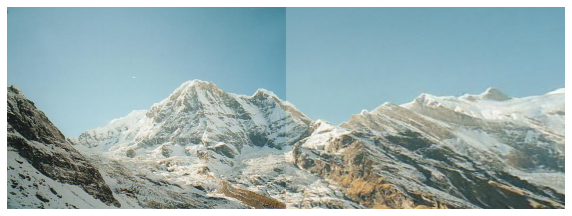

In [8]:
import matplotlib.pyplot as plt
# Load the images
img1 = cv2.imread('images/mountain1.jpg')
img2 = cv2.imread('images/mountain2.jpg')

# Convert colors from BGR to RGB
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Warp the first image according to the homography matrix
img1_warped = cv2.warpPerspective(img1, h_mat, (img1.shape[1] + img2.shape[1], img1.shape[0]))

# Create a new image that will hold the panorama
panorama = np.zeros((max(img1_warped.shape[0], img2.shape[0]), img1_warped.shape[1], 3), dtype=np.uint8)

# Copy the second image to the right side of the panorama
panorama[0:img2.shape[0], 0:img2.shape[1]] = img2

# Now, blend the two images
# First, create a mask where the warped image will be placed
mask = np.all(panorama == 0, axis=2)

# Now copy the warped image into the panorama image
panorama[mask] = img1_warped[mask]

# Display the stitched image
plt.figure(figsize=(10,10))
plt.imshow(panorama)
plt.axis('off')
plt.show()

Exception in Tkinter callback
Traceback (most recent call last):
  File "D:\360Downloads\anaconda\lib\tkinter\__init__.py", line 1892, in __call__
    return self.func(*args)
  File "D:\360Downloads\anaconda\lib\tkinter\__init__.py", line 814, in callit
    func(*args)
  File "D:\360Downloads\anaconda\lib\site-packages\matplotlib\backends\_backend_tk.py", line 476, in delayed_destroy
    self.window.destroy()
  File "D:\360Downloads\anaconda\lib\tkinter\__init__.py", line 2311, in destroy
    for c in list(self.children.values()): c.destroy()
  File "D:\360Downloads\anaconda\lib\tkinter\__init__.py", line 2583, in destroy
    Misc.destroy(self)
  File "D:\360Downloads\anaconda\lib\tkinter\__init__.py", line 640, in destroy
    self.tk.deletecommand(name)
_tkinter.TclError: can't delete Tcl command
Exception in Tkinter callback
Traceback (most recent call last):
  File "D:\360Downloads\anaconda\lib\tkinter\__init__.py", line 1892, in __call__
    return self.func(*args)
  File "D:\360Do

points selected from img1: [(257.31199411331863, 96.5776306107432), (283.11221486387046, 168.8182487122885), (381.15305371596764, 75.93745401030174), (413.83333333333337, 139.57799852832966)]
points selected from img2: [(241.83186166298745, 58.73730684326716), (203.99153789551136, 115.49779249448125), (363.952906548933, 96.5776306107432), (233.2317880794702, 161.93818984547465)]


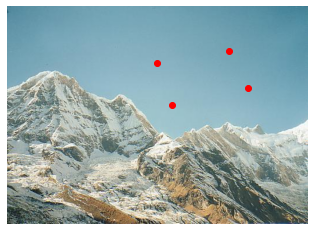

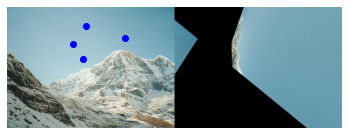

In [37]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('TkAgg')

# Display mountain1.jpg and manually select corresponding points
fig, ax = plt.subplots()
ax.imshow(img1)
points1 = plt.ginput(n=4, show_clicks=True)

print("points selected from img1:",points1)
# Extract x and y coordinates of selected points
u1 = [p[0] for p in points1]
v1 = [p[1] for p in points1]

# Plot selected points on img1
ax.scatter(u1, v1, c='red')
ax.axis('off')
plt.show()

# Display mountain2.jpg and manually select corresponding points
fig, ax = plt.subplots()
ax.imshow(img2)
points2 = plt.ginput(n=4, show_clicks=True)

print("points selected from img2:",points2)
# Extract x and y coordinates of selected points
u2 = [p[0] for p in points2]
v2 = [p[1] for p in points2]

# Plot selected points on img2
ax.scatter(u2, v2, c='blue')
ax.axis('off')
plt.show()

# Calculate homography matrix
H = homography_w_normalisation(u2, v2, u1, v1, img1, img2)

# Warp the mountain1.jpg image using the calculated homography matrix
warped_img1 = cv2.warpPerspective(img1, H, (img1.shape[1], img1.shape[0]))

# Create a blank canvas for the panorama
panorama = np.zeros((max(img2.shape[0], warped_img1.shape[0]), img2.shape[1] + warped_img1.shape[1], 3), dtype=np.uint8)

# Copy mountain2.jpg to the left side of the panorama
panorama[0:img2.shape[0], 0:img2.shape[1]] = img2

# Copy the warped image (mountain1.jpg) to the right side of the panorama
panorama[0:warped_img1.shape[0], img2.shape[1]:] = warped_img1

# Display the final panorama
plt.imshow(panorama)
plt.axis('off')
plt.show()
